In [1]:
import jupyter_black
import torch
import os
from torch import nn
import matplotlib.pyplot as plt
from pathlib import Path
from torchvision import datasets, transforms
from PIL import Image
from torch.utils.data import Dataset, DataLoader

jupyter_black.load()

In [18]:
device = "mps" if torch.backends.mps.is_available() else "CPU"
device

'mps'

## Getting the data for health/disease detection

In [3]:
# import kagglehub

# path = kagglehub.dataset_download("andresmgs/plantdec")
# print("Path to dataset files:", path)

In [4]:
# import shutil

# shutil.copytree(path, "Plant_project", dirs_exist_ok=True)
# print("Data successfully copied to your working folder!")

### fixing the data 

In [5]:
class CustomPlantDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        """
        Args:
            root_dir (Path/str): Path to the split folder (e.g., 'Plant_project_data/train')
            transform (callable, optional): Optional transform to be applied on a sample.
        """
        self.root_dir = Path(root_dir)
        self.images_dir = self.root_dir / "images"
        self.labels_dir = self.root_dir / "labels"

        # List all image files sorted so they align correctly
        self.image_files = sorted(
            [
                f
                for f in os.listdir(self.images_dir)
                if f.endswith((".jpg", ".jpeg", ".png"))
            ]
        )
        self.transform = transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        # 1. Get image path and load it
        img_name = self.image_files[idx]
        img_path = self.images_dir / img_name
        image = Image.open(img_path).convert("RGB")

        # 2. Get corresponding label file path
        label_name = img_name.rsplit(".", 1)[0] + ".txt"
        label_path = self.labels_dir / label_name

        # 3. Read the class ID from the label file (YOLO format: class_id x_center y_center width height)
        # We take the first integer on the first line as the classification label
        label = 0  # Default fallback
        if label_path.exists() and os.path.getsize(label_path) > 0:
            with open(label_path, "r") as f:
                first_line = f.readline().strip().split()
                if first_line:
                    label = int(first_line[0])  # Grab the class ID

        # 4. Apply any transformations
        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

In [6]:
base_data_path = Path("Plant_project_data")

# 2. Append the subfolders
train_dir = base_data_path / "train"
valid_dir = base_data_path / "valid"
test_dir = base_data_path / "test"
data_transform = transforms.Compose(
    [transforms.Resize(size=(64, 64)), transforms.ToTensor()]
)
doc_train_data = CustomPlantDataset(
    root_dir="Plant_project_data/train", transform=data_transform
)
doc_valid_data = CustomPlantDataset(
    root_dir="Plant_project_data/valid", transform=data_transform
)
doc_test_data = CustomPlantDataset(
    root_dir="Plant_project_data/test", transform=data_transform
)

In [7]:
BATCH_SIZE = 32
train_dataloader = DataLoader(
    dataset=doc_train_data, batch_size=BATCH_SIZE, shuffle=True
)
valid_dataloader = DataLoader(
    dataset=doc_valid_data, batch_size=BATCH_SIZE, shuffle=False
)
test_dataloader = DataLoader(
    dataset=doc_test_data, batch_size=BATCH_SIZE, shuffle=False
)

## Getting the data for species identification

In [8]:
# os.environ["KAGGLEHUB_CACHE"] = str(Path("").absolute() / "leafsnap_data")

# 2. Run the download (it will go straight into the folder above)
# path = kagglehub.dataset_download("vandat2601/leafsnap-processed")
# print("Downloaded straight to:", path)

# 3. See what folders are inside it
# print("\nContents of your local folder:")
# print(os.listdir(path))

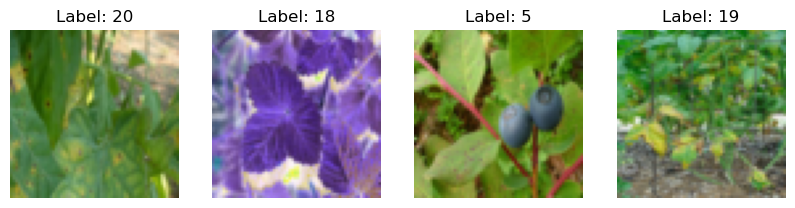

In [9]:
images, labels = next(iter(train_dataloader))

# 2. Set up a grid to plot
plt.figure(figsize=(10, 5))
for i in range(4):
    plt.subplot(1, 4, i + 1)

    # PyTorch images are [Channels, Height, Width], but matplotlib needs [Height, Width, Channels]
    # We use .permute() to swap the dimensions
    img = images[i].permute(1, 2, 0).numpy()

    plt.imshow(img)
    plt.title(f"Label: {labels[i].item()}")
    plt.axis("off")

plt.show()

In [10]:
class PlantHealthClassifierV0(nn.Module):
    """
    Model architecture replicating TinyVGG.
    """

    def __init__(self, input_shape: int, hidden_units: int, output_shape: int) -> None:
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(
                in_channels=input_shape,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1,
            ),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1,
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            # If input is 64x64, after two MaxPool2d(kernel_size=2), it becomes 16x16
            nn.Linear(in_features=hidden_units * 16 * 16, out_features=output_shape),
        )

    def forward(self, x: torch.Tensor):
        return self.classifier(self.conv_block_2(self.conv_block_1(x)))


model_0 = PlantHealthClassifierV0(input_shape=3, hidden_units=20, output_shape=38).to(
    device
)

In [11]:
def train_test_step(
    model: nn.Module, train_dataloader, test_dataloader, loss_fn, optimizer, device
):
    model.train()
    train_loss, train_acc = 0, 0

    for batch, (X, y) in enumerate(train_dataloader):
        X, y = X.to(device), y.to(device)

        y_pred = model(X)

        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item() / len(y_pred)

    # Adjust metrics to get average per batch
    train_loss /= len(train_dataloader)
    train_acc /= len(train_dataloader)

    # evalualting
    model.eval()
    test_loss, test_acc = 0, 0
    with torch.inference_mode():
        for (
            batch,
            (X, y),
        ) in enumerate(test_dataloader):
            X, y = X.to(device), y.to(device)

            test_pred_logits = model(X)
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += (test_pred_labels == y).sum().item() / len(test_pred_labels)

        test_loss /= len(test_dataloader)
        test_acc /= len(test_dataloader)
        return train_loss, train_acc, test_loss, test_acc


loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.01)
train_test_step(model_0, train_dataloader, test_dataloader, loss_fn, optimizer, device)

(3.591616157562502, 0.062182646356033454, 3.54509299993515, 0.046875)

# Training the model for health/disease detection

In [23]:
def EvalModel(EPOCHS, model, loss_fn, optimizer, device):
    EPOCHS = EPOCHS

    # 2. Start the loop
    for epoch in range(EPOCHS):

        # Call your function, passing the clean objects
        train_loss, train_acc, val_loss, val_acc = train_test_step(
            model=model,
            train_dataloader=train_dataloader,
            test_dataloader=valid_dataloader,
            loss_fn=loss_fn,
            optimizer=optimizer,
            device=device,
        )
        if epoch % 5 == 0:
            print(
                f"Epoch:{epoch}|Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%|Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}%"
            )


EvalModel(5, model_0, loss_fn, optimizer, device)

Epoch:0|Train Loss: 3.1463 | Train Acc: 9.61%|Val Loss: 3.0941 | Val Acc: 9.69%


# Improving the model
## Changing the optimizer to Adam

In [13]:
optimizer_1 = torch.optim.Adam(params=model_0.parameters(), lr=0.01)
EvalModel(5, model_0, loss_fn, optimizer_1, device)

Epoch: 1
-------
Train Loss: 4.0239 | Train Acc: 6.66%
Val Loss: 3.2465 | Val Acc: 7.13%
Epoch: 2
-------
Epoch: 3
-------
Epoch: 4
-------
Epoch: 5
-------


## increasing model capacity

In [14]:
model_1 = PlantHealthClassifierV0(input_shape=3, hidden_units=64, output_shape=38).to(
    device
)
optimizer_2 = torch.optim.Adam(params=model_1.parameters(), lr=0.01)

train_test_step(
    model_1, train_dataloader, test_dataloader, loss_fn, optimizer_2, device
)
EvalModel(5, model_1, loss_fn, optimizer_2, device)

Epoch: 1
-------
Train Loss: 3.2843 | Train Acc: 7.03%
Val Loss: 3.2452 | Val Acc: 7.13%
Epoch: 2
-------
Epoch: 3
-------
Epoch: 4
-------
Epoch: 5
-------


## changing learning rate

In [15]:
optimizer_3 = torch.optim.Adam(params=model_1.parameters(), lr=0.001)

train_test_step(
    model_1, train_dataloader, test_dataloader, loss_fn, optimizer_3, device
)
EvalModel(5, model_1, loss_fn, optimizer_3, device)

Epoch: 1
-------
Train Loss: 3.2543 | Train Acc: 7.73%
Val Loss: 3.2246 | Val Acc: 7.13%
Epoch: 2
-------
Epoch: 3
-------
Epoch: 4
-------
Epoch: 5
-------


In [16]:
## reassing model
class PlantHealthClassifierV1(nn.Module):
    """
    Model architecture replicating TinyVGG.
    """

    def __init__(self, input_shape: int, hidden_units: int, output_shape: int) -> None:
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(
                in_channels=input_shape,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1,
            ),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1,
            ),
            nn.BatchNorm2d(hidden_units),  # Added to both convs for maximum stability
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units * 2,
                kernel_size=3,
                padding=1,
            ),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=hidden_units * 2,
                out_channels=hidden_units * 2,
                kernel_size=3,
                padding=1,
            ),
            nn.BatchNorm2d(hidden_units * 2),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            # If input is 64x64, after two MaxPool2d(kernel_size=2), it becomes 16x16
            nn.Linear(in_features=(hidden_units * 2) * 16 * 16, out_features=256),
            nn.ReLU(),
            nn.Dropout(p=0.3),  # Prevents overfitting
            nn.Linear(in_features=256, out_features=output_shape),
        )

    def forward(self, x: torch.Tensor):
        return self.classifier(self.conv_block_2(self.conv_block_1(x)))


model_2 = PlantHealthClassifierV1(input_shape=3, hidden_units=32, output_shape=38).to(
    device
)

In [22]:
optimizer_4 = torch.optim.Adam(params=model_2.parameters(), lr=0.001)
train_test_step(
    model_2, train_dataloader, test_dataloader, loss_fn, optimizer_4, device
)
EvalModel(15, model_2, loss_fn, optimizer_4, device)

Epoch: 1
-------
 Epoch:0Train Loss: 2.8006 | Train Acc: 15.74%|Val Loss: 2.9281 | Val Acc: 17.54%
Epoch: 2
-------
Epoch: 3
-------
Epoch: 4
-------
Epoch: 5
-------
Epoch: 6
-------
 Epoch:5Train Loss: 2.6814 | Train Acc: 16.24%|Val Loss: 3.2004 | Val Acc: 10.88%
Epoch: 7
-------
Epoch: 8
-------
Epoch: 9
-------
Epoch: 10
-------
Epoch: 11
-------
 Epoch:10Train Loss: 2.5445 | Train Acc: 19.44%|Val Loss: 2.9763 | Val Acc: 18.10%
Epoch: 12
-------
Epoch: 13
-------
Epoch: 14
-------
Epoch: 15
-------
